# **Install requirements**

In [ ]:
!pip install comet_ml > /dev/null 2>&1
import comet_ml
# TODO: ENTER YOUR API KEY HERE!! instructions above
COMET_API_KEY = "xNV7ssLfwo53ENbdFvirdm7zV"
# Import Tensorflow 2.0
import tensorflow as tf

# Download and import the MIT Introduction to Deep Learning package
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

# Import all remaining packages
import numpy as np
import os
import time
import functools
from IPython import display as ipythondisplay
from tqdm import tqdm
from scipy.io.wavfile import write
!apt-get install abcmidi timidity > /dev/null 2>&1

I0000 00:00:1789492293.475073   10502 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789492293.478514   10502 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789492293.890054   10502 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789492296.076710   10502 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Dataset

In [ ]:
# Download the dataset
songs = mdl.lab1.load_training_data()

# Print one of the songs to inspect it in greater detail!
example_song = songs[0]
print("\nExample song: ")
print(example_song)

Found 817 songs in text

Example song: 
X:1
T:Alexander's
Z: id:dc-hornpipe-1
M:C|
L:1/8
K:D Major
(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!
dAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!
AG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!
FAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!


In [ ]:
# Convert the ABC notation to audio file and listen to it
mdl.lab1.play_song(example_song)

4.68 February 18 2022 abc2midi
Warning in line-char 11-43 : Assuming repeat
Warning in line-char 11-43 : replacing |: with double repeat (::)
writing MIDI file tmp.mid
Playing tmp.mid
MIDI file: tmp.mid
Format: 0  Tracks: 1  Divisions: 480
Text: note track
Sequence: Alexander's
Text: Z:id:dc-hornpipe-1
Output tmp.wav
Playing time: ~67 seconds
Notes cut: 0
Notes lost totally: 0
Playing tmp.wav
MIDI file: tmp.wav
tmp.wav: Not a MIDI file!


In [ ]:
# Join our list of song strings into a single string containing all songs
songs_joined = "\n\n".join(songs)

# Find all unique characters in the joined string
vocab = sorted(set(songs_joined))
print("There are", len(vocab), "unique characters in the dataset")

There are 83 unique characters in the dataset


## Process the dataset for the learning task

### Vectorize the text

* We'll generate two lookup tables: one that maps characters to numbers, and a second that maps numbers back to characters



In [ ]:
### Define numerical representation of text ###

# Create a mapping from character to unique index.
# For example, to get the index of the character "d",
#   we can evaluate `char2idx["d"]`.
char2idx = {u:i for i, u in enumerate(vocab)}

# Create a mapping from indices to characters. This is
#   the inverse of char2idx and allows us to convert back
#   from unique index to the character in our vocabulary.
idx2char = np.array(vocab)

In [ ]:
print('{')
for char,_ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')

{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '"' :   3,
  '#' :   4,
  "'" :   5,
  '(' :   6,
  ')' :   7,
  ',' :   8,
  '-' :   9,
  '.' :  10,
  '/' :  11,
  '0' :  12,
  '1' :  13,
  '2' :  14,
  '3' :  15,
  '4' :  16,
  '5' :  17,
  '6' :  18,
  '7' :  19,
  ...
}


In [ ]:
### Vectorize the songs string ###

# convert the all songs string to a vectorized (i.e., numeric) representation
def vectorize_string(string):
    vectorized_output = np.array([char2idx[str] for str in string])
    # array with N elements, where N is the number of characters in the string
    return vectorized_output

vectorized_songs = vectorize_string(songs_joined)

In [ ]:
print ('{} ---- characters mapped to int ----> {}'.format(repr(songs_joined[:10]), vectorized_songs[:10]))
# check that vectorized_songs is a numpy array
assert isinstance(vectorized_songs, np.ndarray), "returned result should be a numpy array"

'X:1\nT:Alex' ---- characters mapped to int ----> [49 22 13  0 45 22 26 67 60 79]


### Create training examples and targets
* We'll break the text into chunks of seq_length+1. Suppose seq_length is 4 and our text is "Hello". Then, our input sequence is "Hell" and the target sequence is "ello"

In [ ]:
### Batch definition to create training examples ###

def get_batch(vectorized_songs, seq_length, batch_size):
  # the length of the vectorized songs string
  n = vectorized_songs.shape[0] - 1
  # randomly choose the starting indices for the examples in the training batch
  idx = np.random.choice(n-seq_length, batch_size)

  input_batch = [vectorized_songs[i:i+seq_length] for i in idx ]

  output_batch = [vectorized_songs[i+1: i+seq_length + 1] for i in idx]

  # x_batch, y_batch provide the true inputs and targets for network training
  x_batch = np.reshape(input_batch, [batch_size, seq_length])
  y_batch = np.reshape(output_batch, [batch_size, seq_length])
  return x_batch, y_batch


# Perform some simple tests to make sure your batch function is working properly!
test_args = (vectorized_songs, 10, 2)
if not mdl.lab1.test_batch_func_types(get_batch, test_args) or \
   not mdl.lab1.test_batch_func_shapes(get_batch, test_args) or \
   not mdl.lab1.test_batch_func_next_step(get_batch, test_args):
   print("======\n[FAIL] could not pass tests")
else:
   print("======\n[PASS] passed all tests!")

[PASS] test_batch_func_types
[PASS] test_batch_func_shapes
[PASS] test_batch_func_next_step
[PASS] passed all tests!


In [ ]:
x_batch, y_batch = get_batch(vectorized_songs, seq_length=5, batch_size=1)

for i, (input_idx, target_idx) in enumerate(zip(np.squeeze(x_batch), np.squeeze(y_batch))):
    print("Step {:3d}".format(i))
    print("  input: {} ({:s})".format(input_idx, repr(idx2char[input_idx])))
    print("  expected output: {} ({:s})".format(target_idx, repr(idx2char[target_idx])))

Step   0
  input: 11 (np.str_('/'))
  expected output: 59 (np.str_('d'))
Step   1
  input: 59 (np.str_('d'))
  expected output: 11 (np.str_('/'))
Step   2
  input: 11 (np.str_('/'))
  expected output: 58 (np.str_('c'))
Step   3
  input: 58 (np.str_('c'))
  expected output: 11 (np.str_('/'))
Step   4
  input: 11 (np.str_('/'))
  expected output: 27 (np.str_('B'))


# The Recurrent Neural Network (RNN) model

Three layers are used:

* tf.keras.layers.Embedding: This is the input layer, consisting of a trainable lookup table that maps the numbers of each character to a vector with embedding_dim dimensions.
* tf.keras.layers.LSTM: Our LSTM network, with size units=rnn_units.
* tf.keras.layers.Dense: The output layer, with vocab_size outputs.

### Defining the RNN model

In [ ]:
def LSTM(rnn_units):
  return tf.keras.layers.LSTM(
    rnn_units,
    return_sequences=True,
    recurrent_initializer='glorot_uniform',
    recurrent_activation='sigmoid',
    stateful=True,
  )

In [ ]:
### Defining the RNN Model ###

def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
    # Layer 1: Embedding layer to transform indices into dense vectors of a fixed embedding size
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    # Layer 2: LSTM with `rnn_units` number of units.
    LSTM(rnn_units),
    # Layer 3: Dense (fully-connected) layer that transforms the LSTM output into the vocabulary size.
    tf.keras.layers.Dense(vocab_size)
    ])
    return model

# Build a simple model with default hyperparameters. You will get the
#   chance to change these later.
model = build_model(len(vocab), embedding_dim=256, rnn_units=1024, batch_size=32)
model.build(tf.TensorShape([32, 100]))  # [batch_size, sequence_length]

E0000 00:00:1789492305.338187   10502 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Test out the RNN model

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 100, 256)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (32, 100, 1024)        │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 100, 83)          │        85,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,353,299 (20.42 MB)

 Trainable params: 5,353,299 (20.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
x, y = get_batch(vectorized_songs, seq_length=100, batch_size=32)
pred = model(x)
print("Input shape:      ", x.shape, " # (batch_size, sequence_length)")
print("Prediction shape: ", pred.shape, "# (batch_size, sequence_length, vocab_size)")

Input shape:       (32, 100)  # (batch_size, sequence_length)
Prediction shape:  (32, 100, 83) # (batch_size, sequence_length, vocab_size)


### Predictions from the untrained model

In [ ]:
sampled_indices = tf.random.categorical(pred[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices,axis=-1).numpy()
sampled_indices

array([27, 26, 41,  9, 24,  6, 78, 78, 66, 32, 37,  6, 34, 26, 24, 73, 47,
        3, 34, 49, 43, 12,  6, 28, 50,  7, 56,  1, 34, 30, 82, 50, 64, 35,
       73, 68, 59, 23, 46,  7, 79, 40, 59, 64, 52, 60,  6, 63, 61, 69, 16,
        8, 71, 51,  0, 28, 20, 43,  9, 21, 19,  4, 75, 65, 18, 20, 39, 67,
       32, 38, 22, 70, 65, 73, 18, 26, 34, 29, 57, 69, 79,  4, 30, 11, 10,
       22, 67, 47,  3, 28, 29, 77, 17, 77, 69, 21, 55, 73, 18,  8])

In [ ]:
print("Input: \n", repr("".join(idx2char[x[0]])))
print()
print("Next Char Predictions: \n", repr("".join(idx2char[sampled_indices])))

Input: 
 'e2cA BAFB|!\nABcA B2cB|ABcA BAFA|d3c dfed|cdBc A2:|!\nef|e2cd edcd|edcA BAFf|e2cd edcA|BdcA BAFf|!\ne2c'

Next Char Predictions: 
 'BAP-=(wwkGL(IA=rV"IXR0(CY)a IE|YiJrmd<U)xOdi[e(hfn4,pZ\nC8R-97#tj68NlGM:ojr6AIDbnx#E/.:lV"CDv5vn9_r6,'


# Training the model: loss and training operations

In [ ]:
### Defining the loss function ###

def compute_loss(labels, logits):
    loss = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
    return loss

example_batch_loss = compute_loss(y, pred)

print("Prediction shape: ", pred.shape, " # (batch_size, sequence_length, vocab_size)")
print("scalar_loss:      ", example_batch_loss.numpy().mean())

Prediction shape:  (32, 100, 83)  # (batch_size, sequence_length, vocab_size)
scalar_loss:       4.418327


In [ ]:
### Hyperparameter setting and optimization ###

vocab_size = len(vocab)

# Model parameters:
params = dict(
  num_training_iterations = 200,  # Increase this to train longer
  batch_size = 8,  # Experiment between 1 and 64
  seq_length = 100,  # Experiment between 50 and 500
  learning_rate = 5e-3,  # Experiment between 1e-5 and 1e-1
  embedding_dim = 256,
  rnn_units = 1024,  # Experiment between 1 and 2048
)

# Checkpoint location:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "my_ckpt.weights.h5")
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
### Create a Comet experiment to track our training run ###

def create_experiment():
  # end any prior experiments
  if 'experiment' in locals():
    experiment.end()

  # initiate the comet experiment for tracking
  experiment = comet_ml.Experiment(
                  api_key=COMET_API_KEY,
                  project_name="6S191_Lab1_Part2")
  # log our hyperparameters, defined above, to the experiment
  for param, value in params.items():
    experiment.log_parameter(param, value)
  experiment.flush()

  return experiment

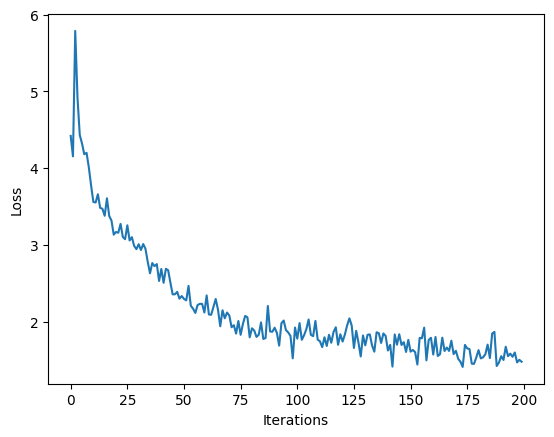

100%|██████████| 200/200 [08:47<00:00,  2.64s/it]
COMET INFO: Uploading 4 metrics, params and output messages


True

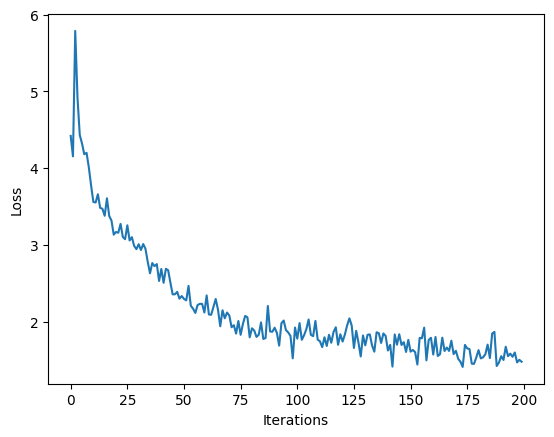

In [ ]:
### Define optimizer and training operation ###

model = build_model(len(vocab), params["embedding_dim"], params["rnn_units"], params["batch_size"])

optimizer = tf.keras.optimizers.Adam(params["learning_rate"])

@tf.function
def train_step(x, y):
  # Use tf.GradientTape()
  with tf.GradientTape() as tape:
    y_hat = model(x)
    loss = compute_loss(y, y_hat)
  # Now, compute the gradients
  grads = tape.gradient(loss, model.trainable_variables)
  # Apply the gradients to the optimizer so it can update the model accordingly
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  return loss

##################
# Begin training!#
##################

history = []
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss')
experiment = create_experiment()

if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists
for iter in tqdm(range(params["num_training_iterations"])):
  # Grab a batch and propagate it through the network
  x_batch, y_batch = get_batch(vectorized_songs, params["seq_length"], params["batch_size"])
  loss = train_step(x_batch, y_batch)
  # log the loss to the Comet interface! we will be able to track it there.
  experiment.log_metric("loss", loss.numpy().mean(), step=iter)
  # Update the progress bar and also visualize within notebook
  history.append(loss.numpy().mean())
  plotter.plot(history)

  # Update the model with the changed weights!
  if iter % 100 == 0:
    model.save_weights(checkpoint_prefix)

# Save the trained model and the weights
model.save_weights(checkpoint_prefix)
experiment.flush()

# Generate music using the RNN model

In [ ]:
# Restore the latest checkpoint

model = build_model(vocab_size, params["embedding_dim"], params["rnn_units"], batch_size=1)
# Restore the model weights for the last checkpoint after training
model.build(tf.TensorShape([1, None]))
model.load_weights(checkpoint_prefix)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (1, None, 256)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (1, None, 1024)        │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, None, 83)          │        85,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,353,299 (20.42 MB)

 Trainable params: 5,353,299 (20.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Prediction of a generated song ###
def generate_text(model, start_string, generation_length=1000):
  # Evaluation step (generating ABC text using the learned RNN model)

  input_eval = [char2idx[str] for str in start_string]
  input_eval = tf.expand_dims(input_eval, 0)

  # Empty string to store our results
  text_generated = []

  # Here batch size == 1
  for layer in model.layers:
    if hasattr(layer, "reset_states"):
      layer.reset_states()

  tqdm._instances.clear()

  for i in tqdm(range(generation_length)):
    predictions = model(input_eval)
    # Remove the batch dimension
    predictions = tf.squeeze(predictions, 0)
    predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()

    # Pass the prediction along with the previous hidden state
    #   as the next inputs to the model
    input_eval = tf.expand_dims([predicted_id], 0)

    text_generated.append(idx2char[predicted_id])

  return (start_string + ''.join(text_generated))

In [ ]:
generated_text = generate_text(model, start_string="X", generation_length=1000)

100%|██████████| 1000/1000 [00:22<00:00, 44.76it/s]


## Play back the generated music!

*Audio player output stripped to keep the notebook lightweight; listen here:* [example_song.wav](example_song.wav)

In [ ]:
### Play back generated songs ###

generated_songs = mdl.lab1.extract_song_snippet(generated_text)

for i, song in enumerate(generated_songs):
  # Synthesize the waveform from a song
  waveform = mdl.lab1.play_song(song)

  # If its a valid song (correct syntax), lets play it!
  if waveform:
    print("Generated song", i)
    ipythondisplay.display(waveform)

    numeric_data = np.frombuffer(waveform.data, dtype=np.int16)
    wav_file_path = f"output_{i}.wav"
    write(wav_file_path, 88200, numeric_data)

    # save your song to the Comet interface -- you can access it there
    experiment.log_asset(wav_file_path)
# when done, end the comet experiment
experiment.end()

rm: cannot remove 'tmp.mid': No such file or directory


Found 3 songs in text
4.68 February 18 2022 abc2midi
Error in line-char 13-0 : No tune processed. Possible missing X: field
Playing tmp.mid
MIDI file: tmp.mid
tmp.mid: No such file or directory
Playing tmp.wav
MIDI file: tmp.wav
tmp.wav: Not a MIDI file!
4.68 February 18 2022 abc2midi
Warning in line-char 4-0 : No / found, assuming denominator of 1
Warning in line-char 8-98 : Ignoring reserved character U
Warning in line-char 14-46 : Assuming repeat
Warning in line-char 14-46 : replacing |: with double repeat (::)
Warning in line-char 14-46 : Assuming repeat
Warning in line-char 14-46 : replacing |: with double repeat (::)
writing MIDI file tmp.mid
Warning in line-char 7-10 : Track 0 Bar 1 has 7/8 time units while the time signature has 6
Warning in line-char 7-14 : Track 0 Bar 2 has 3/8 time units while the time signature has 6
Warning in line-char 7-22 : Track 0 Bar 3 has 3/4 time units while the time signature has 6
Warning in line-char 7-31 : Track 0 Bar 4 has 7/8 time units while 

4.68 February 18 2022 abc2midi
Warning in line-char 13-54 : Assuming repeat
writing MIDI file tmp.mid
Warning in line-char 7-12 : Track 0 Bar 1 has 7/2 time units while the time signature has 4
Warning in line-char 7-21 : Track 0 Bar 2 has 7/2 time units while the time signature has 4
Warning in line-char 9-12 : Track 0 Bar 3 has 13/2 time units while the time signature has 4
Warning in line-char 7-3 : Track 0 Bar 0 has 3/2 time units while the time signature has 4 in repeat
Warning in line-char 7-12 : Track 0 Bar 1 has 7/2 time units while the time signature has 4 in repeat
Warning in line-char 7-21 : Track 0 Bar 2 has 7/2 time units while the time signature has 4 in repeat
Warning in line-char 9-12 : Track 0 Bar 3 has 13/2 time units while the time signature has 4 in repeat
Warning in line-char 10-2 : Track 0 Bar 4 has 1 time units while the time signature has 4 in repeat
Warning in line-char 12-7 : Track 0 Bar 5 has 6 time units while the time signature has 4
Warning in line-char 12

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : consistent_border_4554
COMET INFO:     url                   : https://www.comet.com/cristian-macias/6s191-lab1-part2/04d97289125b4eefbf79b24134fa3ea9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [200] : (1.4087862968444824, 5.787059307098389)
COMET INFO:   Parameters:
COMET INFO:     batch_size              : 8
COMET INFO:     embedding_dim           : 256
COMET INFO:     learning_rate           : 0.005
COMET INFO:     num_training_iterations : 200
COMET INFO:     rnn_units               : 1024
COMET INFO:     seq_length              : 100
COMET INFO:   Uploads:
COMET INFO:     asset                    : 2 (29.40 MB)
COMET INFO:   

*Audio player outputs stripped to keep the notebook lightweight; listen here:* [output_1.wav](output_1.wav) · [output_2.wav](output_2.wav)